In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tqdm import tqdm

import os
import glob
import cv2

from keras.utils import normalize

from skimage.io import imread, imshow
from skimage.transform import resize

In [2]:
from tensorflow import keras

In [3]:
data_seis = np.load('C:\\Users\\DELL\\2D Seismic\\train_seismic.npy', 
               allow_pickle=True, mmap_mode = 'r')
print(data_seis.shape)

data_lab = np.load('C:\\Users\\DELL\\2D Seismic\\train_labels.npy', 
               allow_pickle=True, mmap_mode = 'r')
print(data_lab.shape)

(401, 701, 255)
(401, 701, 255)


In [3]:
for i in tqdm(range(0, data_seis.shape[0])):
  img = np.transpose(data_seis[i])
  label = np.transpose(data_lab[i])

  img = np.expand_dims(img, axis=2).astype('float32')
  label = np.expand_dims(label, axis=2).astype('float32')

  img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  label = cv2.resize(label, (256,256), interpolation = cv2.INTER_AREA)
  img = cv2.resize(img, (256,256), interpolation = cv2.INTER_AREA)

  label = np.around(label)
  label = label.astype(np.uint8)

  cv2.imwrite('C:\\Users\\DELL\\train_imgs\\image_x_%03d.png' % i, img)
  cv2.imwrite('C:\\Users\\DELL\\train_labels\\image_x_%03d.png' % i, label)

100%|██████████| 401/401 [00:35<00:00, 11.30it/s]


In [4]:
x_300 = cv2.imread('C:\\Users\\DELL\\train_imgs\\image_x_300.png')
x_300_l = cv2.imread('C:\\Users\\DELL\\train_labels\\image_x_300.png', cv2.IMREAD_UNCHANGED)

print(x_300.shape)
print(x_300_l.shape)

(256, 256, 3)
(256, 256)


In [4]:
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 3

path = 'C:\\Users\\DELL\\train_imgs\\'
path2 = 'C:\\Users\\DELL\\train_labels\\'

train_ids = next(os.walk(path))[2]
train_ids2 = next(os.walk(path2))[2]

In [5]:
X_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
Y_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.uint8)
#X_test = np.zeros((len(test_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)

for n, id_ in tqdm(enumerate(train_ids), total=len(train_ids)):
    img = cv2.imread(path + id_)
    #img = cv2.resize(img, (128,128))
    X_train[n] = img
    
for n, id_ in tqdm(enumerate(train_ids2), total=len(train_ids2)):
    img2 = cv2.imread(path2 + id_)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY) # converting rgb to greyscale
    img2 = np.expand_dims(resize(img2, (IMG_HEIGHT, IMG_WIDTH), mode='constant',
                                 preserve_range=True), axis=-1) # Resizing to 128 by 128 by 1
    #img2 = cv2.resize(img2, (128,128))
    Y_train[n] = img2

100%|██████████| 401/401 [00:12<00:00, 31.79it/s]


(-0.5, 255.5, 255.5, -0.5)

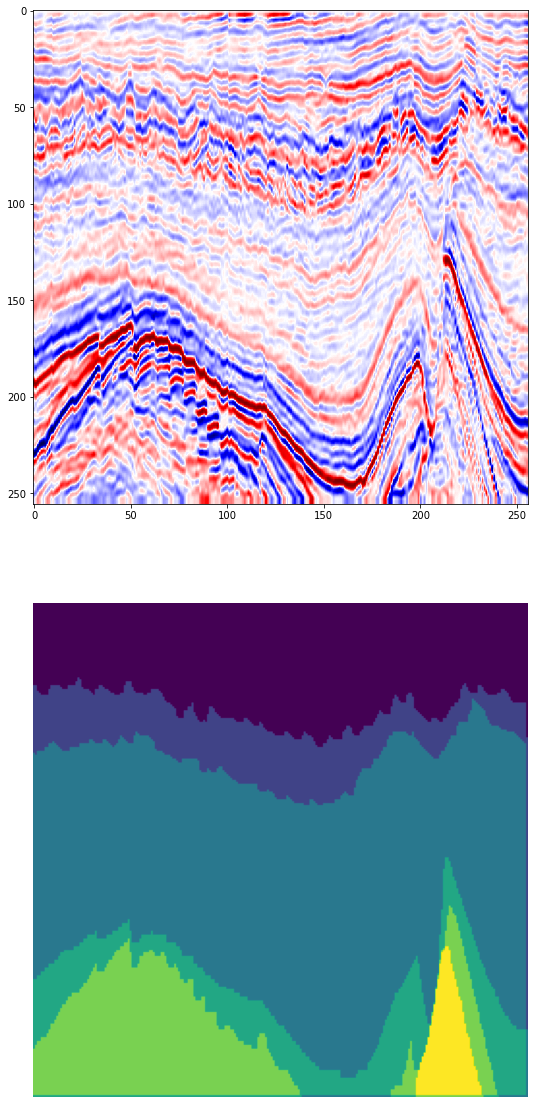

In [12]:
plt.rcParams["figure.figsize"] = (20, 20)
f, ax = plt.subplots(2,1)
#f.subplots_adjust(hspace=0.5, wspace=0)

ax[0].imshow(X_train[1][:,:,0], cmap='seismic_r')
plt.axis('off')
ax[1].imshow(np.squeeze(Y_train[1]))
plt.axis('off')

In [6]:
print(X_train.shape)
print(Y_train.shape)

(401, 256, 256, 3)
(401, 256, 256, 1)


In [20]:
#Build the model
inputs = tf.keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)

#Contraction path
c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
c1 = tf.keras.layers.Dropout(0.1)(c1)
c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
c2 = tf.keras.layers.Dropout(0.1)(c2)
c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
 
c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
c3 = tf.keras.layers.Dropout(0.2)(c3)
c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
 
c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
c4 = tf.keras.layers.Dropout(0.2)(c4)
c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)
 
c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
c5 = tf.keras.layers.Dropout(0.3)(c5)
c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

#Expansive path 
u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = tf.keras.layers.concatenate([u6, c4])
c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
c6 = tf.keras.layers.Dropout(0.2)(c6)
c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
 
u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = tf.keras.layers.concatenate([u7, c3])
c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
c7 = tf.keras.layers.Dropout(0.2)(c7)
c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
 
u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = tf.keras.layers.concatenate([u8, c2])
c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
c8 = tf.keras.layers.Dropout(0.1)(c8)
c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
 
u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
c9 = tf.keras.layers.Dropout(0.1)(c9)
c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
 
outputs = tf.keras.layers.Conv2D(n_classes, (1, 1), activation='softmax')(c9)
 
model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
lambda_1 (Lambda)               (None, 256, 256, 3)  0           input_2[0][0]                    
__________________________________________________________________________________________________
conv2d_19 (Conv2D)              (None, 256, 256, 16) 448         lambda_1[0][0]                   
__________________________________________________________________________________________________
dropout_9 (Dropout)             (None, 256, 256, 16) 0           conv2d_19[0][0]                  
_______________________________________________________________________________________

In [7]:
np.unique(Y_train)

array([0, 1, 2, 3, 4, 5], dtype=uint8)

In [8]:
n_classes = 6
from keras.utils import to_categorical
Y_train_cat = to_categorical(Y_train, num_classes=n_classes)
Y_train_cat = Y_train_cat.reshape((Y_train.shape[0], Y_train.shape[1], Y_train.shape[2], n_classes))
Y_train_cat.shape

(401, 256, 256, 6)

In [9]:
np.unique(Y_train_cat)

array([0., 1.], dtype=float32)

In [21]:
callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=2, monitor='val_loss'),
        tf.keras.callbacks.TensorBoard(log_dir='logs')]

In [82]:
history = model.fit(X_train, Y_train_cat,
                   batch_size = 10,
                   epochs=40,
                   verbose=1,
                   #class_weight=classweights,
                    callbacks=callbacks,
                   shuffle=False)

Epoch 1/40
41/41 [==============================] - 338s 8s/step - loss: 0.0432 - accuracy: 0.9492
Epoch 2/40
41/41 [==============================] - 337s 8s/step - loss: 0.0450 - accuracy: 0.9355
Epoch 3/40
41/41 [==============================] - 334s 8s/step - loss: 0.0384 - accuracy: 0.9454
Epoch 4/40
41/41 [==============================] - 333s 8s/step - loss: 0.0403 - accuracy: 0.9440
Epoch 5/40
41/41 [==============================] - 335s 8s/step - loss: 0.0334 - accuracy: 0.9553
Epoch 6/40
41/41 [==============================] - 334s 8s/step - loss: 0.0320 - accuracy: 0.9565
Epoch 7/40
41/41 [==============================] - 330s 8s/step - loss: 0.0326 - accuracy: 0.9561
Epoch 8/40
41/41 [==============================] - 331s 8s/step - loss: 0.0325 - accuracy: 0.9563
Epoch 9/40
41/41 [==============================] - 25545s 623s/step - loss: 0.0292 - accuracy: 0.9598
Epoch 10/40
41/41 [==============================] - 304s 7s/step - loss: 0.0270 - accuracy: 0.9626
Epoch

41/41 [==============================] - 306s 7s/step - loss: 0.0155 - accuracy: 0.9814
Epoch 28/40
41/41 [==============================] - 306s 7s/step - loss: 0.0150 - accuracy: 0.9818
Epoch 29/40
41/41 [==============================] - 306s 7s/step - loss: 0.0145 - accuracy: 0.9824
Epoch 30/40
41/41 [==============================] - 316s 8s/step - loss: 0.0140 - accuracy: 0.9829
Epoch 31/40
41/41 [==============================] - 308s 8s/step - loss: 0.0140 - accuracy: 0.9829
Epoch 32/40
41/41 [==============================] - 30209s 737s/step - loss: 0.0141 - accuracy: 0.9829
Epoch 33/40
41/41 [==============================] - 312s 8s/step - loss: 0.0141 - accuracy: 0.9830
Epoch 34/40
41/41 [==============================] - 314s 8s/step - loss: 0.0143 - accuracy: 0.9827
Epoch 35/40
41/41 [==============================] - 307s 7s/step - loss: 0.0139 - accuracy: 0.9832
Epoch 36/40
41/41 [==============================] - 305s 7s/step - loss: 0.0138 - accuracy: 0.9834
Epoch 37

In [23]:
model.save('2D_Seismic_Prediction_weights.hdf5')

In [83]:
model.save('2D_Seismic_Prediction_weights_40Ep.hdf5')

In [2]:
test_seis = np.load('C:\\Users\\DELL\\2D Seismic\\test1_seismic.npy', 
               allow_pickle=True, mmap_mode = 'r')
print(test_seis.shape)

test_lab = np.load('C:\\Users\\DELL\\2D Seismic\\test1_labels.npy', 
               allow_pickle=True, mmap_mode = 'r')
print(test_lab.shape)

(200, 701, 255)
(200, 701, 255)


In [4]:
import os
import numpy as np
import cv2
from tqdm import tqdm

In [5]:
for i in tqdm(range(0, test_seis.shape[0])):
  img = np.transpose(test_seis[i])
  label = np.transpose(test_lab[i])

  img = np.expand_dims(img, axis=2).astype('float32')
  label = np.expand_dims(label, axis=2).astype('float32')

  img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  label = cv2.resize(label, (256,256), interpolation = cv2.INTER_AREA)
  img = cv2.resize(img, (256,256), interpolation = cv2.INTER_AREA)

  label = np.around(label)
  label = label.astype(np.uint8)

  cv2.imwrite('C:\\Users\\DELL\\test_imgs\\image_y_%03d.png' % i, img)
  cv2.imwrite('C:\\Users\\DELL\\test_labels\\image_y_%03d.png' % i, label)

100%|██████████| 200/200 [00:43<00:00,  4.56it/s]


In [26]:
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 3

path = 'C:\\Users\\DELL\\test_imgs\\'
path2 = 'C:\\Users\\DELL\\test_labels\\'

test_ids = next(os.walk(path))[2]
test_ids2 = next(os.walk(path2))[2]

X_test = np.zeros((len(test_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
Y_test = np.zeros((len(test_ids), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.uint8)
#X_test = np.zeros((len(test_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)

for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
    img = cv2.imread(path + id_)
    #img = cv2.resize(img, (128,128))
    X_test[n] = img
    
for n, id_ in tqdm(enumerate(test_ids2), total=len(test_ids2)):
    img2 = cv2.imread(path2 + id_)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY) # converting rgb to greyscale
    img2 = np.expand_dims(resize(img2, (IMG_HEIGHT, IMG_WIDTH), mode='constant',
                                 preserve_range=True), axis=-1) # Resizing to 128 by 128 by 1
    #img2 = cv2.resize(img2, (128,128))
    Y_test[n] = img2

100%|██████████| 200/200 [00:03<00:00, 53.30it/s]


In [27]:
print(X_test.shape)
print(Y_test.shape)

(200, 256, 256, 3)
(200, 256, 256, 1)


In [28]:
np.unique(Y_test)

array([0, 1, 2, 3, 4, 5], dtype=uint8)

In [29]:
from keras.utils import to_categorical
Y_test_cat = to_categorical(Y_test, num_classes=n_classes)
Y_test_cat = Y_test_cat.reshape((Y_test.shape[0], Y_test.shape[1], Y_test.shape[2], n_classes))
Y_test_cat.shape

(200, 256, 256, 6)

In [84]:
_, acc = model.evaluate(X_test, Y_test_cat)
print("Accuracy is =", (acc * 100.0), "%")

7/7 [==============================] - 35s 5s/step - loss: 0.3183 - accuracy: 0.8446
Accuracy is = 84.4567358493805 %


In [31]:
y_pred = model.predict(X_test)
y_pred_argmax =np.argmax(y_pred, axis=3)

In [85]:
y_pred2 = model.predict(X_train)
y_pred2_argmax =np.argmax(y_pred2, axis=3)

In [34]:
from sklearn.preprocessing import LabelEncoder
labelEncoder = LabelEncoder()
n,h,w = 200,256,256
test_masks_reshaped = Y_test.reshape(-1,1)
test_masks_reshaped_encoded = labelEncoder.fit_transform(test_masks_reshaped)
test_masks_encoded_orig = test_masks_reshaped_encoded.reshape(n,h,w)

np.unique(test_masks_encoded_orig)

array([0, 1, 2, 3, 4, 5], dtype=int64)

In [86]:
from keras.metrics import MeanIoU
n_classes = 6
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(test_masks_encoded_orig[:,:,:], y_pred_argmax)
print("Mean_IOU =", IOU_keras.result().numpy())

Mean_IOU = 0.44440675


In [87]:
values = np.array(IOU_keras.get_weights()).reshape(n_classes, n_classes)
print(values)
class1_IoU = values[0,0]/(values[0,0]+values[0,1]+values[0,2]+values[0,3]+values[0,4]+values[0,5])
class2_IoU = values[1,1]/(values[1,1]+values[1,0]+values[1,2]+values[1,3]+values[1,4]+values[1,5])
class2_IoU = values[2,2]/(values[2,2]+values[2,0]+values[2,1]+values[2,3]+values[2,4]+values[2,5])
class3_IoU = values[3,3]/(values[3,3]+values[3,0]+values[3,1]+values[3,2]+values[3,4]+values[3,5])
class4_IoU = values[4,4]/(values[4,4]+values[4,0]+values[4,1]+values[4,2]+values[4,3]+values[4,5])
class5_IoU = values[5,5]/(values[5,5]+values[5,0]+values[5,1]+values[5,2]+values[5,3]+values[5,4])

print("IoU for class1 ia: ", class1_IoU)
print("IoU for class2 ia: ", class2_IoU)
print("IoU for class3 ia: ", class3_IoU)
print("IoU for class4 ia: ", class4_IoU)
print("IoU for class5 ia: ", class5_IoU)
print("IoU for class5 ia: ", class5_IoU)

[[2.495132e+06 7.794800e+04 4.000000e+00 0.000000e+00 1.560000e+02
  0.000000e+00]
 [2.098960e+05 9.288720e+05 1.498490e+05 4.840000e+02 2.222000e+03
  0.000000e+00]
 [1.444100e+04 6.418400e+04 5.777141e+06 5.402900e+04 2.994000e+03
  0.000000e+00]
 [2.038000e+03 2.168500e+04 1.033620e+05 7.838760e+05 1.668700e+04
  0.000000e+00]
 [4.885000e+03 6.928300e+04 8.352590e+05 1.236141e+06 3.752200e+04
  0.000000e+00]
 [1.440000e+03 1.749000e+03 1.584490e+05 5.591000e+04 1.562000e+03
  0.000000e+00]]
IoU for class1 ia:  0.969646049338577
IoU for class2 ia:  0.9770585420856385
IoU for class3 ia:  0.8450144882541654
IoU for class4 ia:  0.017187564415576086
IoU for class5 ia:  0.0
IoU for class5 ia:  0.0


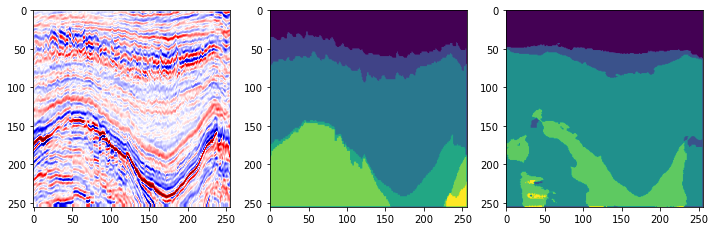

In [96]:
import random
test_img_number = random.randint(0, len(X_test))
test_img = X_test[test_img_number]
ground_truth = Y_test[test_img_number]
#test_img_norm=test_img[:,:,0][:,:,None]
#test_img_input=np.expand_dims(test_img_norm, 0)
prediction = y_pred_argmax[test_img_number]
#predicted_img=np.argmax(prediction, axis=3)#[0,:,:]

plt.figure(figsize=(12,8))
plt.subplot(231)
plt.imshow(test_img[:,:,0], cmap='seismic_r')
plt.subplot(232)
plt.imshow(ground_truth[:,:,0])
plt.subplot(233)
plt.imshow(prediction)
plt.show()

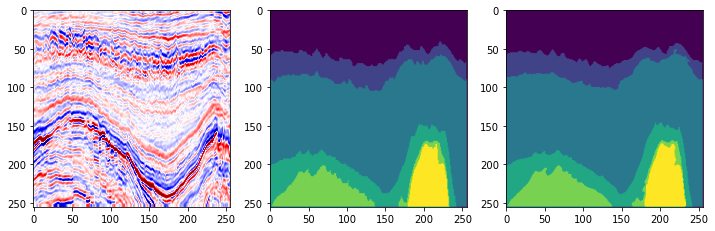

In [97]:
import random
train_img_number = random.randint(0, len(X_train))
train_img = X_train[train_img_number]
ground_truth = Y_train[train_img_number]
#test_img_norm=test_img[:,:,0][:,:,None]
#test_img_input=np.expand_dims(test_img_norm, 0)
prediction = y_pred2_argmax[train_img_number]
#predicted_img=np.argmax(prediction, axis=3)#[0,:,:]

plt.figure(figsize=(12,8))
plt.subplot(231)
plt.imshow(test_img[:,:,0], cmap='seismic_r')
plt.subplot(232)
plt.imshow(ground_truth[:,:,0])
plt.subplot(233)
plt.imshow(prediction)
plt.show()

In [62]:
from sklearn.preprocessing import LabelEncoder
labelEncoder = LabelEncoder()
n,h,w = 401,256,256
train_masks_reshaped = Y_train.reshape(-1,1)
train_masks_reshaped_encoded = labelEncoder.fit_transform(train_masks_reshaped)
train_masks_encoded_orig = train_masks_reshaped_encoded.reshape(n,h,w)

np.unique(train_masks_encoded_orig)

array([0, 1, 2, 3, 4, 5], dtype=int64)

In [66]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced',np.unique(train_masks_reshaped_encoded),
                                                  train_masks_reshaped_encoded)
print("Classes weights are :", class_weights)

Classes weights are : [ 0.58450499  1.37966238  0.34515103  2.53651128  5.32789028 11.74820513]


In [71]:
cls_wgt = {0:0.58450499, 1:1.37966238, 2:0.34515103, 3:2.53651128, 4:5.32789028, 5:11.74820513}

In [79]:
#Build the model
inputs = tf.keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)

#Contraction path
c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
c1 = tf.keras.layers.Dropout(0.1)(c1)
c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
c2 = tf.keras.layers.Dropout(0.1)(c2)
c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
 
c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
c3 = tf.keras.layers.Dropout(0.2)(c3)
c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
 
c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
c4 = tf.keras.layers.Dropout(0.2)(c4)
c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)
 
c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
c5 = tf.keras.layers.Dropout(0.3)(c5)
c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

#Expansive path 
u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = tf.keras.layers.concatenate([u6, c4])
c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
c6 = tf.keras.layers.Dropout(0.2)(c6)
c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
 
u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = tf.keras.layers.concatenate([u7, c3])
c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
c7 = tf.keras.layers.Dropout(0.2)(c7)
c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
 
u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = tf.keras.layers.concatenate([u8, c2])
c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
c8 = tf.keras.layers.Dropout(0.1)(c8)
c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
 
u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
c9 = tf.keras.layers.Dropout(0.1)(c9)
c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
 
outputs = tf.keras.layers.Conv2D(n_classes, (1, 1), activation='softmax')(c9)
 
model2 = tf.keras.Model(inputs=[inputs], outputs=[outputs])
model2.compile(optimizer='adam', loss=weightedLoss(keras.losses.categorical_crossentropy, cls_wgt), metrics=['accuracy'])
model2.summary()

Model: "functional_9"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
lambda_4 (Lambda)               (None, 256, 256, 3)  0           input_5[0][0]                    
__________________________________________________________________________________________________
conv2d_76 (Conv2D)              (None, 256, 256, 16) 448         lambda_4[0][0]                   
__________________________________________________________________________________________________
dropout_36 (Dropout)            (None, 256, 256, 16) 0           conv2d_76[0][0]                  
_______________________________________________________________________________________

In [81]:
history2 = model2.fit(X_train, Y_train_cat,
                   batch_size = 10,
                   epochs=25,
                   verbose=1,
                   #class_weight=cls_wgt,
                    callbacks=callbacks,
                   shuffle=False)

Epoch 1/25


ValueError: in user code:

    C:\Users\DELL\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:806 train_function  *
        return step_function(self, iterator)
    C:\Users\DELL\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:796 step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    C:\Users\DELL\anaconda3\lib\site-packages\tensorflow\python\distribute\distribute_lib.py:1211 run
        return self._extended.call_for_each_replica(fn, args=args, kwargs=kwargs)
    C:\Users\DELL\anaconda3\lib\site-packages\tensorflow\python\distribute\distribute_lib.py:2585 call_for_each_replica
        return self._call_for_each_replica(fn, args, kwargs)
    C:\Users\DELL\anaconda3\lib\site-packages\tensorflow\python\distribute\distribute_lib.py:2945 _call_for_each_replica
        return fn(*args, **kwargs)
    C:\Users\DELL\anaconda3\lib\site-packages\tensorflow\python\keras\engine\training.py:789 run_step  **
       

In [76]:
def weightedLoss(originalLossFunc, weightList):
    def lossFunc(true, pred):
        axis = -1
        
        classSelectors = K.argmax(true, axis=axis)
        
        classSelectors = [K.equal(i, classSelectors) for i in range(len(weightsList))]
        
        classSelectors = [K.cast(x, K.floatx()) for x in classSelectors]
        
        weights = [sel* sel for sel,w in zip(classSelectors, weightList)]
        
        weightmultiplier = weights[0]
        for i in range(1, len(weights)):
            weightMultiplier = weightMultiplier + weights[i]
            
            loss = originalLossFunc(true,pred)
            loss = loss * weighMultiplier
            
            return loss
        return lossFunc
    